In [2]:
import pybamm
import matplotlib.pyplot as plt

dr_p = 1.
dr_n = 0.9

param = pybamm.ParameterValues("Chen2020")
param["Positive electrode active material volume fraction"] *= dr_p
param["Negative electrode active material volume fraction"] *= dr_n

PBM_model = pybamm.lithium_ion.SPM()

experiment = pybamm.Experiment(["Charge at 1C for 100000 seconds or until 4.2 V"])
sim = pybamm.Simulation(PBM_model, experiment=experiment, parameter_values=param)
solution = sim.solve(initial_soc=0.05)

t_1 = solution["Time [s]"].entries
V_1 = solution["Terminal voltage [V]"].entries

In [2]:
dr_p = 0.8745727
dr_n = 0.874162

param = pybamm.ParameterValues("Chen2020")
param["Positive electrode active material volume fraction"] *= dr_p
param["Negative electrode active material volume fraction"] *= dr_n

PBM_model = pybamm.lithium_ion.SPM()

experiment = pybamm.Experiment(["Charge at 1C for 100000 seconds or until 4.2 V"])
sim = pybamm.Simulation(PBM_model, experiment=experiment, parameter_values=param)
solution = sim.solve(initial_soc=0.05)

t_2 = solution["Time [s]"].entries
V_2 = solution["Terminal voltage [V]"].entries

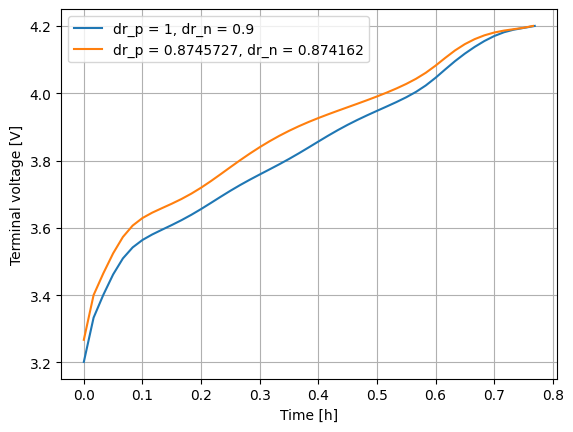

In [3]:
# Plot v1 and v2

plt.plot(t_1/3600., V_1, label="dr_p = 1, dr_n = 0.9")
plt.plot(t_2/3600., V_2, label="dr_p = 0.8745727, dr_n = 0.874162")
plt.xlabel("Time [h]")
plt.ylabel("Terminal voltage [V]")
plt.legend()
plt.grid()
plt.show()

In [11]:
dr_p = 0.9
dr_n = 1.

param = pybamm.ParameterValues("Chen2020")
param["Positive electrode active material volume fraction"] *= dr_p
param["Negative electrode active material volume fraction"] *= dr_n

PBM_model = pybamm.lithium_ion.SPM()

experiment = pybamm.Experiment(["Discharge at 1C for 100000 seconds or until 3 V"])
sim = pybamm.Simulation(PBM_model, experiment=experiment, parameter_values=param)
solution = sim.solve(initial_soc=1.)

t_1 = solution["Time [s]"].entries
V_1 = solution["Terminal voltage [V]"].entries

dr_p = 1.
dr_n = 1.

param = pybamm.ParameterValues("Chen2020")
param["Positive electrode active material volume fraction"] *= dr_p
param["Negative electrode active material volume fraction"] *= dr_n

PBM_model = pybamm.lithium_ion.SPM()

experiment = pybamm.Experiment(["Discharge at 1C for 100000 seconds or until 3 V"])
sim = pybamm.Simulation(PBM_model, experiment=experiment, parameter_values=param)
solution = sim.solve(initial_soc=1.)

t_2 = solution["Time [s]"].entries
V_2 = solution["Terminal voltage [V]"].entries

plt.plot(t_1/3600., V_1, label="dr_p = 1, dr_n = 0.9")
plt.plot(t_2/3600., V_2, label="dr_p = 0.8745727, dr_n = 0.874162")
plt.xlabel("Time [h]")
plt.ylabel("Terminal voltage [V]")
plt.legend()
plt.grid()
plt.show()

KeyboardInterrupt: 

In [5]:
param

{'Ambient temperature [K]': 298.15,
 'Boltzmann constant [J.K-1]': 1.380649e-23,
 'Bulk solvent concentration [mol.m-3]': 2636.0,
 'Cation transference number': 0.2594,
 'Cell cooling surface area [m2]': 0.00531,
 'Cell thermal expansion coefficient [m.K-1]': 1.1e-06,
 'Cell volume [m3]': 2.42e-05,
 'Contact resistance [Ohm]': 0,
 'Current function [A]': 5.0,
 'EC diffusivity [m2.s-1]': 2e-18,
 'EC initial concentration in electrolyte [mol.m-3]': 4541.0,
 'Electrode height [m]': 0.065,
 'Electrode width [m]': 1.58,
 'Electrolyte conductivity [S.m-1]': <function electrolyte_conductivity_Nyman2008 at 0x000001A21F1E60C0>,
 'Electrolyte diffusivity [m2.s-1]': <function electrolyte_diffusivity_Nyman2008 at 0x000001A21F1E6020>,
 'Electron charge [C]': 1.602176634e-19,
 'Faraday constant [C.mol-1]': 96485.33212,
 'Ideal gas constant [J.K-1.mol-1]': 8.314462618,
 'Initial concentration in electrolyte [mol.m-3]': 1000.0,
 'Initial concentration in negative electrode [mol.m-3]': 29866.0,
 'Initi

In [14]:
import pybamm
import matplotlib.pyplot as plt

param = pybamm.ParameterValues("Chen2020")

dr_p = 1.
dr_n = 1.
param["Positive electrode active material volume fraction"] *= dr_p
param["Negative electrode active material volume fraction"] *= dr_n

PBM_model = pybamm.lithium_ion.SPM()

experiment = pybamm.Experiment(["Discharge at 0.01C for 1000000 seconds or until 2.5 V"])
sim = pybamm.Simulation(PBM_model, experiment=experiment, parameter_values=param)
solution = sim.solve(initial_soc=1.)

t = solution["Time [s]"].entries
V = solution["Terminal voltage [V]"].entries

# PybaMM concentrations
c_s_n = solution["Negative particle concentration"]
c_s_p = solution["Positive particle concentration"]
r_n = solution["r_n [m]"].entries[:, 0, 0]
r_p = solution["r_p [m]"].entries[:, 0, 0]
t_pbm = solution["Time [s]"].entries
x = solution["x [m]"].entries[:, 0]

c_p_pbm = c_s_p(r=r_p[-1], t=t, x=x[-1])
c_n_pbm = c_s_n(r=r_n[-1], t=t, x=x[0])

# Faraday's constant
F = 96485
# Cell area
A = param["Electrode height [m]"] * param["Electrode width [m]"]
# Cell thickness
L_p = param["Positive electrode thickness [m]"]
# Active material volume fraction
eps_p = param["Positive electrode active material volume fraction"]
# Maximum concentration
c_p_max = param["Maximum concentration in positive electrode [mol.m-3]"]
print("Q_p:", A * F * L_p * eps_p * c_p_max * (c_p_pbm[-1] - c_p_pbm[0]) / 3600)

# Negative electrode thickness
L_n = param["Negative electrode thickness [m]"]
# Active material volume fraction
eps_n = param["Negative electrode active material volume fraction"]
# Maximum concentration
c_n_max = param["Maximum concentration in negative electrode [mol.m-3]"]
print("Q_n:", A * F * L_n * eps_n * c_n_max * (c_n_pbm[0] - c_n_pbm[-1]) / 3600)

# Print stoichiometries
print("y_0:", c_n_pbm[0])
print("y_100:", c_n_pbm[-1])
print("x_0:", c_p_pbm[0])
print("x_100:", c_p_pbm[-1])
print(solution['x_p [m]'].entries)

Q_p: 5.156852937013448
Q_n: 5.152154703439307
y_0: 0.9106121196114546
y_100: 0.026515902276965892
x_0: 0.26384918007154967
x_100: 0.8543991784369546
[[9.9090e-05 9.9090e-05 9.9090e-05 ... 9.9090e-05 9.9090e-05 9.9090e-05]
 [1.0287e-04 1.0287e-04 1.0287e-04 ... 1.0287e-04 1.0287e-04 1.0287e-04]
 [1.0665e-04 1.0665e-04 1.0665e-04 ... 1.0665e-04 1.0665e-04 1.0665e-04]
 ...
 [1.6335e-04 1.6335e-04 1.6335e-04 ... 1.6335e-04 1.6335e-04 1.6335e-04]
 [1.6713e-04 1.6713e-04 1.6713e-04 ... 1.6713e-04 1.6713e-04 1.6713e-04]
 [1.7091e-04 1.7091e-04 1.7091e-04 ... 1.7091e-04 1.7091e-04 1.7091e-04]]


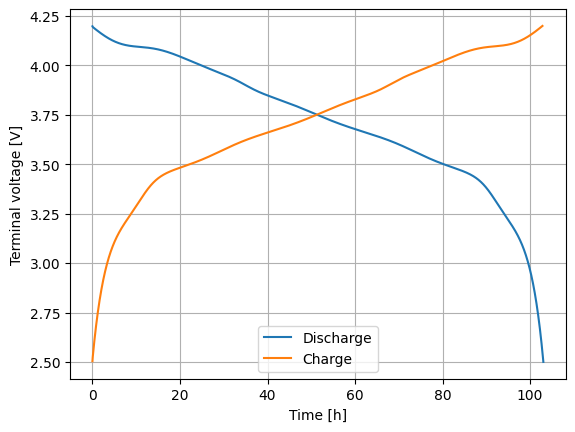

In [21]:
import pybamm
import matplotlib.pyplot as plt

param = pybamm.ParameterValues("Chen2020")

PBM_model = pybamm.lithium_ion.SPM()

experiment = pybamm.Experiment(["Discharge at 0.01C for 1000000 seconds or until 2.5 V"])
sim = pybamm.Simulation(PBM_model, experiment=experiment, parameter_values=param)
solution = sim.solve(initial_soc=1.)

t_dch = solution["Time [s]"].entries
V_dch = solution["Terminal voltage [V]"].entries

experiment = pybamm.Experiment(["Charge at 0.01C for 1000000 seconds or until 4.2 V"])
sim = pybamm.Simulation(PBM_model, experiment=experiment, parameter_values=param)
solution = sim.solve(initial_soc=0.)

t_ch = solution["Time [s]"].entries
V_ch = solution["Terminal voltage [V]"].entries

plt.plot(t_dch/3600., V_dch, label="Discharge")
plt.plot(t_ch/3600., V_ch, label="Charge")
plt.xlabel("Time [h]")
plt.ylabel("Terminal voltage [V]")
plt.legend()
plt.grid()
plt.show()